In [1]:
import sys
import os

# 1. Add the build folder to Python's search path
sys.path.append(os.path.abspath("build"))

In [2]:
import specbridge as sb

In [3]:
n_clusters = 4

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Reproducible synthetic data from 4 clearly separated 2D clusters
rng = np.random.default_rng(42)
points_per_cluster = 5_000_000
cluster_std = 0.8
centers = np.array([
    [-6.0, -6.0],
    [ 6.0, -6.0],
    [-6.0,  6.0],
    [ 6.0,  6.0],
])

X_parts = []
for c in centers:
    X_parts.append(rng.normal(loc=c, scale=cluster_std, size=(points_per_cluster, 2)))

X = np.vstack(X_parts).astype(np.float32)

kmeans = sb.KMeans(n_clusters=n_clusters, random_state=42)


Total processors: 12, threads: 1
Total processors: 12, threads: 1
Total processors: 12, threads: 2
Total processors: 12, threads: 4
Total processors: 12, threads: 6
Total processors: 12, threads: 8
Total processors: 12, threads: 12
Total processors: 12, threads: 24


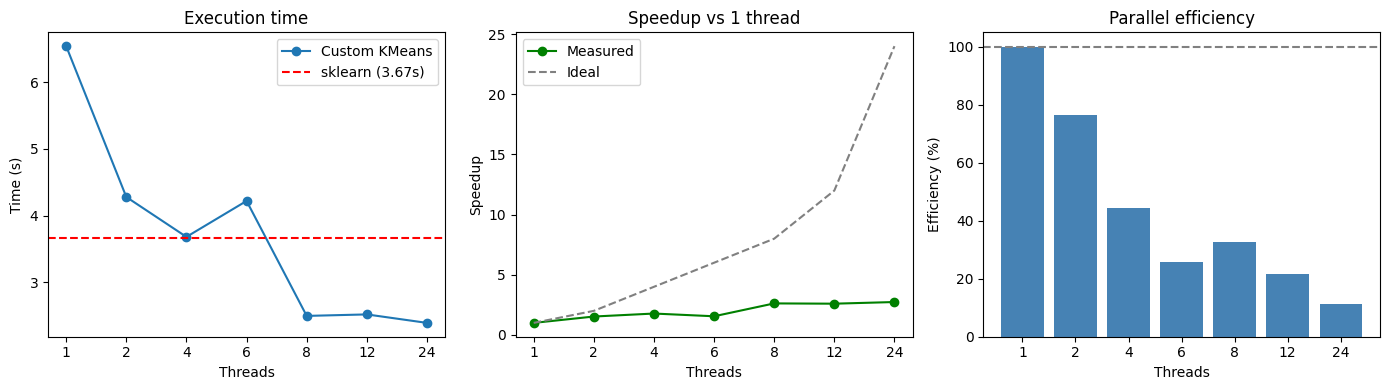

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.cluster import KMeans as skKMeans

# --- WARMUP RUN ---
# Gets memory loaded and page faults out of the way
sb.set_num_threads(1)
kmeans.fit(X)

thread_counts = [1, 2, 4, 6, 8, 12, 24]
custom_times = []

for n in thread_counts:
    sb.set_num_threads(n)
    t0 = time.perf_counter()
    kmeans.fit(X)
    custom_times.append(time.perf_counter() - t0)

X = X.astype(np.float32) 

sk = skKMeans(
    n_clusters=4, 
    n_init=1, 
    max_iter=20, 
    algorithm='lloyd', 
    init='k-means++',    # <--- CHANGE THIS: Your C++ code is doing K-Means++!
    tol=0.0,             # Matches your C++ strict 20 iterations
    random_state=42
)

sk.fit(X)  # warm-up
t0 = time.perf_counter()
sk.fit(X)
sklearn_time = time.perf_counter() - t0

base = custom_times[0]
speedups   = [base / t for t in custom_times]
ideal      = [t / thread_counts[0] for t in thread_counts]
efficiency = [s / t * 100 for s, t in zip(speedups, thread_counts)]

x      = np.arange(len(thread_counts))
labels = [str(t) for t in thread_counts]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Time ---
axes[0].plot(x, custom_times, 'o-', label='Custom KMeans')
axes[0].axhline(sklearn_time, linestyle='--', color='red', label=f'sklearn ({sklearn_time:.2f}s)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Execution time')
axes[0].legend()

# --- Speedup ---
axes[1].plot(x, speedups, 'o-', color='green', label='Measured')
axes[1].plot(x, ideal, '--', color='gray', label='Ideal')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup vs 1 thread')
axes[1].legend()

# --- Efficiency ---
axes[2].bar(x, efficiency, color='steelblue')
axes[2].axhline(100, linestyle='--', color='gray')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_xlabel('Threads')
axes[2].set_ylabel('Efficiency (%)')
axes[2].set_title('Parallel efficiency')

plt.tight_layout()
plt.show()